LADINENI DIVIJA     
25215011116


LAB 3: Apply a Gaussian Mixture Model(GMM) to a two-dimensional array to perform soft clustering and visualize the learned decision boundaries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture


In [ ]:
# Generate 2D data with 3 clusters
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)


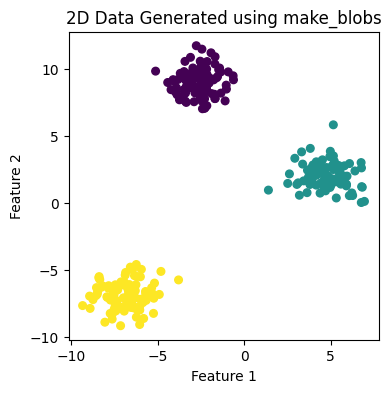

In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)

plt.title("2D Data Generated using make_blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [ ]:
# Fit Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X)

# Predict cluster labels (soft clustering → converted to hard labels)
labels = gmm.predict(X)


In [ ]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax, **kwargs):
    # Eigenvalues & eigenvectors
    eigenvals, eigenvecs = np.linalg.eigh(covariance)

    # Sort eigenvalues
    order = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    # Angle of ellipse
    angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))

    # Width & height (2 std devs)
    width, height = 2 * np.sqrt(eigenvals)

    ellipse = Ellipse(
        xy=position,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)


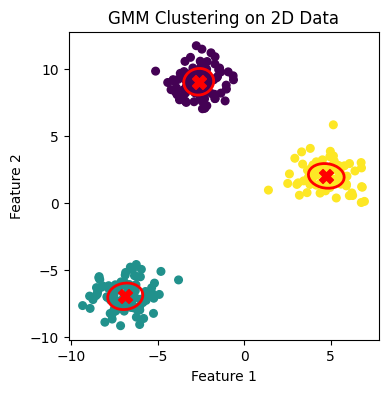

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

# Scatter plot colored by predicted cluster
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)

# Plot Gaussian ellipses and centers
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, edgecolor='red', linewidth=2)
    ax.scatter(mean[0], mean[1], c='red', s=100, marker='X')

ax.set_title("GMM Clustering on 2D Data")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()


In [ ]:
print("Converged Means:")
print(gmm.means_)

print("\nCovariance Matrices:")
for i, cov in enumerate(gmm.covariances_):
    print(f"\nComponent {i}:")
    print(cov)


Converged Means:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]

Covariance Matrices:

Component 0:
[[0.74869031 0.04368399]
 [0.04368399 0.98715159]]

Component 1:
[[1.02961821 0.09574043]
 [0.09574043 0.98277206]]

Component 2:
[[ 1.07033552 -0.09844297]
 [-0.09844297  0.85003382]]
